# This notebook documents the UQ of the Amaducci2018 $^{10}$B(n,$\alpha$)/$^{6}$Li(n,$\alpha$) cs experimental data for the Standards. (Data release: LA-UR-25-32229)

In [1]:
import os
from importlib import reload
from numpy import array, shape, diag, arange, ones, zeros, loadtxt, sqrt, meshgrid
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
homedir = os.getcwd() +'/'

In [5]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [7]:
import Class_nfcs_legacy as Cnf
reload(Cnf)

<module 'Class_nfcs_legacy' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs_legacy.py'>

In [9]:
datafile = homedir+'Amaducci2019_20binsperdecade.txt'
alldata  = loadtxt(datafile)
Einc = alldata[:,0]*.5e-6 + alldata[:,1]*.5e-6
ratio = alldata[:,2] # absolute B-10(n,a)/Li-6(n,t).
statunc = alldata[:,3]*100.0/alldata[:,2]
nodata  = shape(statunc)[0]

normB = 6.0 # % might not apply if re-normalized. Ask Allan to read p. 8-10, Sections 2.3 and 3.1.
normLi = 1.5 #% might not apply if re-normalized. Not applied and used as shape measurement because they did not correct for sample-thickness effects.
normU = 1.0 #% might not apply if re-normalized. Not applied and used as shape measurement because they did not correct for sample-thickness effects.

In [11]:
#variationaluncB  = 1.0*ones(nodata,dtype=float) #%, they made some cuts in the data, and then varied the cut which then gives these uncertainties. This is a det eff. unc.
#variationaluncLi = 0.3*ones(nodata,dtype=float) #%, they made some cuts in the data, and then varied the cut which then gives these uncertainties. This is a det eff. unc.
# I took the variational uncertainties out after Allan pointed out they are considered by the authors normalization uncertainties.

attenuation = zeros(nodata,dtype=float) #% beam attenuation at low energies.
forwardangle = zeros(nodata,dtype=float) #% above 1 keV.

Eunc = zeros(nodata,dtype=float)

for index in arange(0,nodata):
    if Einc[index] < 0.001: # keV
        attenuation[index ] = 0.3
    elif Einc[index] > 0.001: 
        forwardangle[index] = 1.0

bacgkroundunc = 0.2*ones(nodata,dtype=float) #10% of the background correction. A run was performed with the real sam- ples replaced by the dummy ones, and the background at all the neutron energies was found well below 10−3 for
# the lithium and uranium samples with respect to the re- action count rates, therefore it was neglected in the anal- ysis. For the boron samples we found that above 1keV neutron energy this background contributed ≈ 2% and was subtracted. 

Text(0, 0.5, 'Relative Uncertainty (%)')

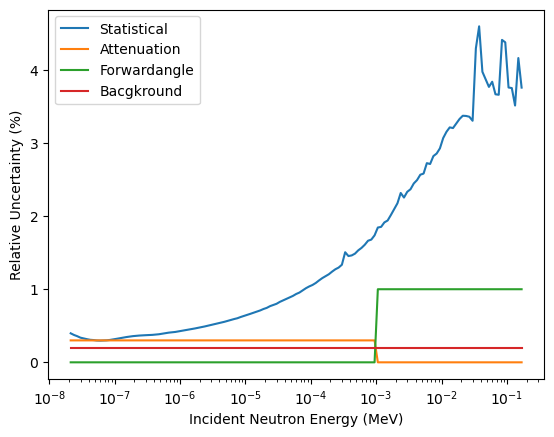

In [13]:
plt.semilogx(Einc,statunc,label='Statistical')
plt.semilogx(Einc,attenuation,label="Attenuation")
plt.semilogx(Einc,forwardangle,label="Forwardangle")
plt.semilogx(Einc,bacgkroundunc,label="Bacgkround")
plt.legend()
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

In [15]:
features = {"Author": ["S. Amaducci", "L. Cosentino", "M. Barbagallo", "N. Colonna", "A. Mengoni", "C. Massimi", "S. Lo Meo", "P. Finocchiaro", "C. Guerrero", "et al."],
"Year": "2019",
"Facility": ["SYNCY","2ZZZCER"],
"Institute": ["2ITYLNS","2ITYBAU","2ITYBOL","2ITYUBO","2ZZZCER","2FR SAC","2SPNPCM","2SWTPSI","2PRTLFE","2GERPTB","2UK MAN","2UK YRK",\
"2GERFRK","2AUSVIE","3AULCBR","2JPNJAE","2FR PAR","2SPNUPC"],
"Isotope": ["Li-6", "B-10"],
'quantity': 'cs ratio', 'reaction': 'n,a',\
'MeasurementType':'Clean ratio shape',\
'Absolute':'n',
'ConcernEXFOR':'N/A',\
"BackgroundCorrected": "y",\
"AlphaBackground": "y",\
"GammaBackground": "y",\
"RandomCoincidenceBackground": "N/A",\
"ShadowBarBackground": "n",\
"WrapAroundBackground": "N/A",\
"MultipleScatteringSampleBackingCorrected": "n",\
"MultipleScatteringSurroundingCorrected": "y",\
"AttenuationSampleBackingCorrected": "n",\
"AttenuationSurroundingCorrected": "y",\
"FissionDetectionEfficiencyCorrected": "y",\
"NeutronDetectionEfficiencyCorrected": "y",\
"NeutronDetectionResponseCorrected": "y",\
"SampleDecayCorrected": "unknown",
"FissionFragmentAbsorptioninSampleCorrected": "y",
"SignalPulsePileupCorrected": "y",
"DeadtimeCorrected": "y",
"AngularDistributionFissionFragmentsCorrected": "unknown",
"ImpuritiesCorrected": "y",
'ForwardBoostCorrected':'N/A',\
'SpectrumExtrapolationCorrected':'N/A',\
'GeometryCorrected':'y','NeutronFluxVariationCorrected':'y',\
"CorrelatedData": ["23453008", "23453009", "23453011", "23453012"],\
"EXFORnumber": "23453010",\
"Accepted": "y",\
"ChargedParticleDetector": {"Type": "SI","number":6,\
"ParticleDetected": ["FF","a","t"],\
"Efficiency": 96.8,\
"EfficiencyMethod": ["ratio to 6Li(n,t)"],
"FFAbsorptionAngularDistributionMethod": "unknown",
"AngularAcceptaneofFF": 360.0,
"Gas": { "Type": "N/A", "Purity": "N/A", "Pressure": "N/A" },
"Size": { "geometry": "planar", "dimensions": [50, 50, 200], "dimensions_unit":["mm","mm","mum"] },
"NoPhotomultipliers": "N/A",
"Weight": "unknown",
"StructuralMaterial": ["Si","Al"],
"ReferenceDetector": "SI"},
"Shielding": {"Material": "Aluminum, concrete (beamline)","Size": "unknown",\
"DistanceFromNeutronDetector": "unknown",\
"Purpose": "reduce gamma and scattered neutron background"},
"Sample": {"Activity": "N/A","Activity_unit": "N/A","Reused": "no",\
"Form": "metal","Mass": "unknown",\
"Diameter": {"Li-6": 47, "B-10": 70,"U-235": 40}, "Diameter_unit":"mm",\
"Thickness": {"Li-6": 1.97, "B-10": 0.080,"U-235": 0.145},
"Thickness_unit":"mum",
"Homogenity": "uniform deposition verified by optical inspection and weighing",
"Contaminants":{"Li6": {'6Li':0.95}, "B10": {'10B':0.99},"U235": {'235U':99.999}},
'BackingMaterial':'Al','BackingDiameter':['47x47','70x70','40'],'Diameter_unit':'N/A',
'BackingThickness':{"Li-6": 50.0, "B-10": 18.0,"U-235": 250.0},\
'BackingThickness_unit':'mum','DecayDeterminationMethod':'N/A',\
'Configuration':'parallel plate',\
'Fabrication':{"Li-6": 'evaporation', "B-10": 'plasma deposition',"U-235": 'molecular plating'},\
'ImpurityDetermination':'unknown'},
"BackgroundMethods": {
"General": ["beam-off subtraction","PhD","timing correlation with TOF signal"],
"Wraparound": "N/A",
"alpha": ["thresholding","PhD"],
"Gamma": ["PhD","energy calibration from standards"],
"RandomCoincidence": "timing correlation with TOF signal"},
"MultipleScatteringMethods": {"InSample": "neglected due to thin targets","Surrounding": "MC"},
"AttenuationMethods": {"InSample": "neglected due to thin targets","Surrounding":"MC"},
"DeadtimeDeterminationMethod": "live-time normalization from DAQ system",
'EnergyDetermination':'TOF',\
'NeutronBeam':{'Facility':['SYNCY,2ZZZCER'],'PulseWidth':625.0,'PulseWidthUnit':'mus',
'NeutronProducingReaction':'p,W','Target':'W',\
'EnergySpread':'unknown','Monitor':'235U FISCH',\
'Diameter':0.5,'Diameter_unit':'cm','TimeGateOpen':50.0,'TimeGateOpen_unit':'mus',
'TOFLength':{'Value':183.49,'Unit': 'm','Unc':0.02,'Unit_Unc':'m'},\
'trsl':{'Value':1.7,'Unit':'ns','Measure':'1-sigma'},\
't0Determination':'gamma flash'}     
}

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

{'isotope': 'B-10', 'quantity': 'cs', 'reaction': 'n,a', 'identifier': 'ENDF/B-VII.1'}
{'isotope': 'Li-6', 'quantity': 'cs', 'reaction': 'n,t', 'identifier': 'ENDF/B-VII.1'}
deriv_nucdata: [-1.07564754e+04 -1.28656876e+04 -1.36433436e+04 -1.76487344e+04
 -1.92592291e+04 -1.64411530e+04 -1.58865482e+04 -1.52302014e+04
 -9.05445171e+03 -7.33741244e+03 -6.04306817e+02  1.00022715e+04
  1.87792686e+04  2.61374717e+04  2.27642145e+04  1.10459405e+04
 -6.49441447e+03 -2.16058336e+04 -2.79902546e+04 -2.41273480e+04
 -1.25356934e+04 -6.45855234e+03 -3.13892830e+03 -3.22

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs_legacy.py:2114: UserWarning: Warning: Minimum outgoing energy of experiment smaller than that of the reference data.
  warn(msg)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


{'isotope': 'Li-6', 'quantity': 'cs', 'reaction': 'n,t', 'identifier': 'ENDF/B-VII.1'}
Testing covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


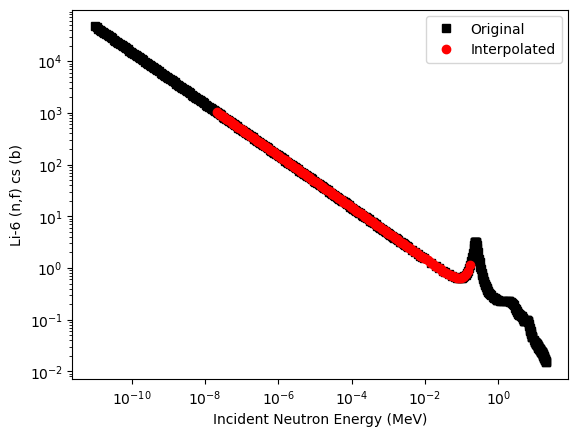

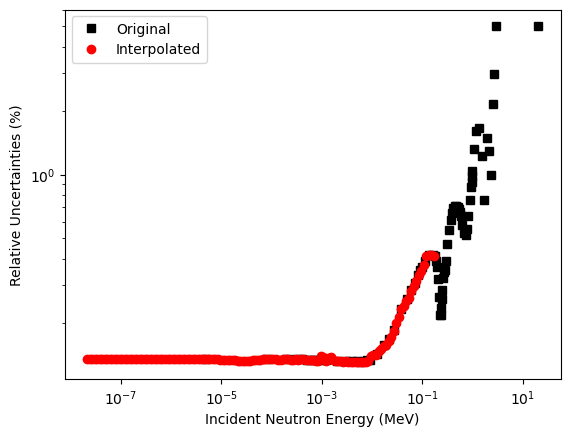

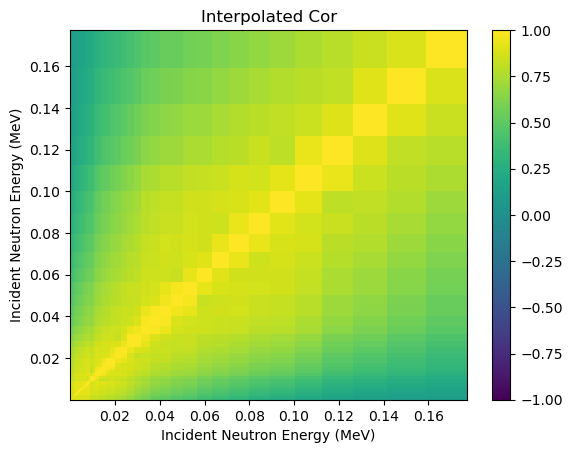

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/B-10/nacs_Amaducci2019/nacs_Amaducci2019.xml
{'isotope': 'B-10', 'quantity': 'cs', 'reaction': 'n,a', 'identifier': 'ENDF/B-VII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/B-10/nacs_Amaducci2019/nacs_Amaducci2019EUCLID.json
{'isotope': 'B-10', 'quantity': 'cs', 'reaction': 'n,a', 'identifier': 'ENDF/B-VII.1'}
{'isotope': 'Li-6', 'quantity': 'cs', 'reaction': 'n,t', 'identifier': 'ENDF/B-VII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/B-10/nacs_Amaducci2019/nacs_Amaducci2019ratiodataEUCLID.json

Output file saved in file: /Users/dneudecker/Documents

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


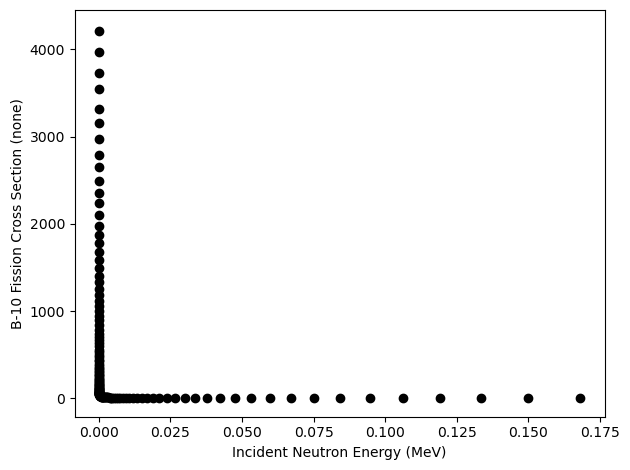

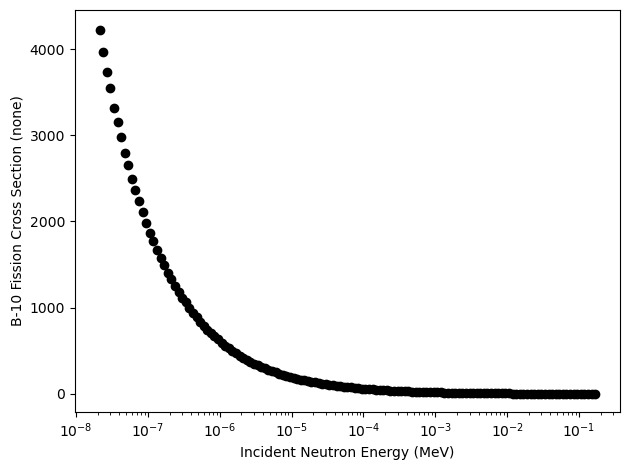

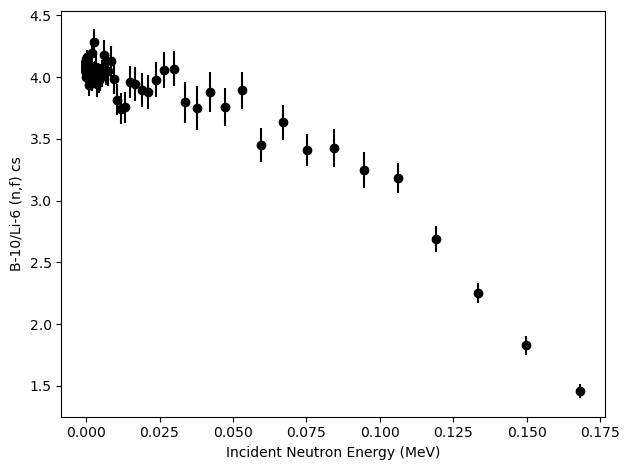

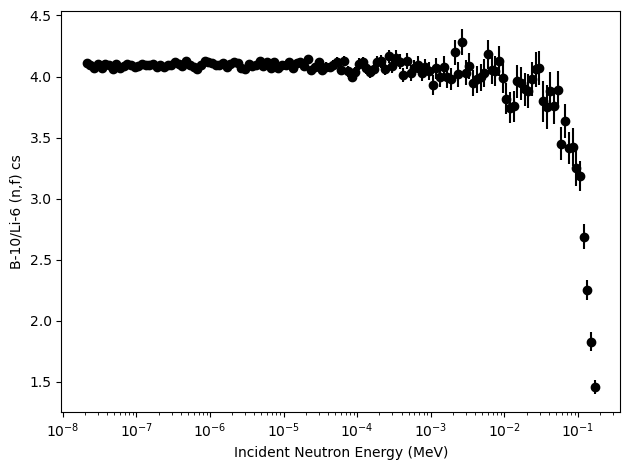

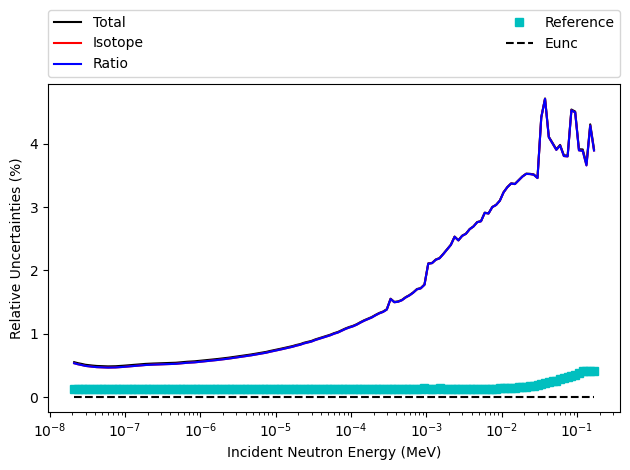

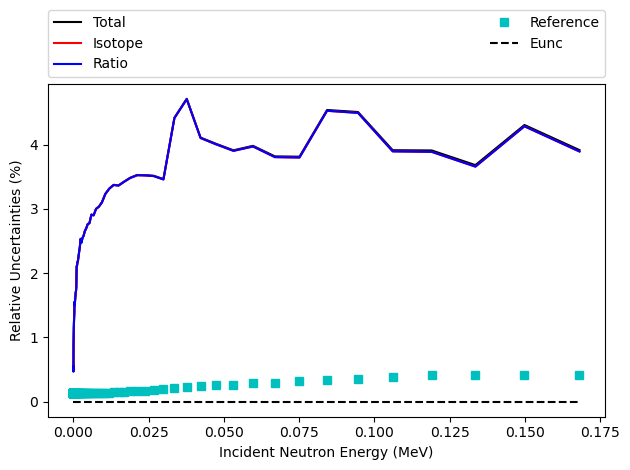

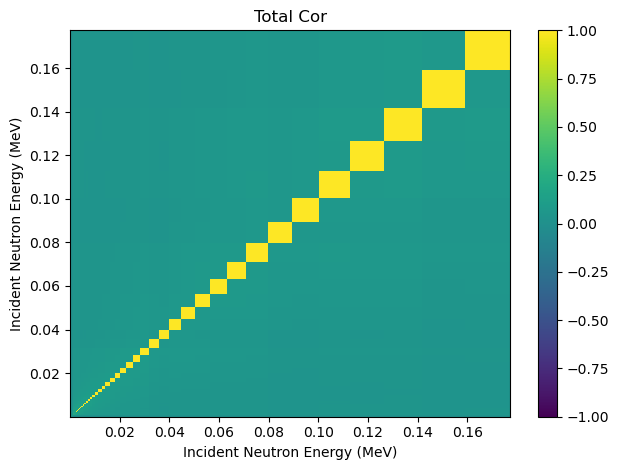

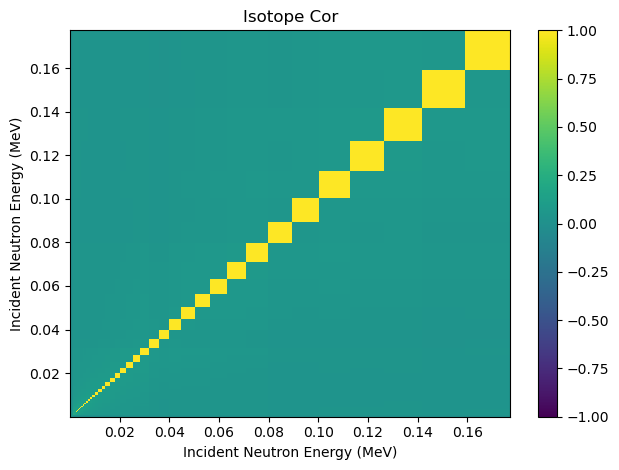

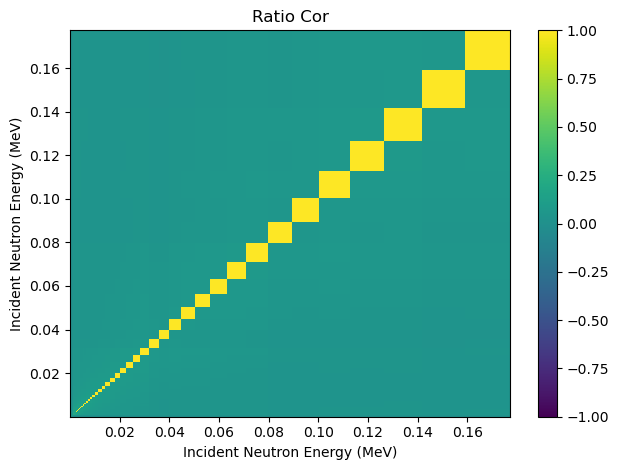

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/MatrixFunctions.py:44: RuntimeWarning: invalid value encountered in scalar divide
  cor[index1,index2] = cov[index1,index2]/\


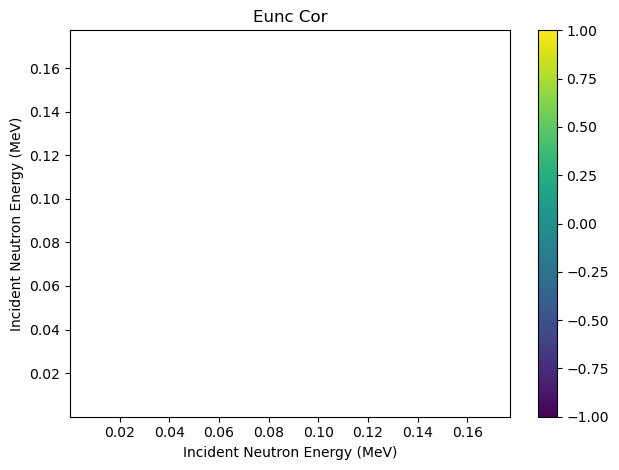

In [21]:
Documentation = """"EXFOR No. = 23453010. Journal article = European Physical Journal A: Hadrons and Nuclei, Vol.55, p.120 (2019), Germany. \
# EXFOR uncertainties are: statistical only.
# Additional uncertainties: variational uncertainties (eff cut) for B-10, Li-6, attenuation, forward angle, background unc.
# The data are shape data of B-10/L-6.
# No issue found."""

norm_unc = {'value': 1.0, 'unit':'%'}

general_info = {'name': 'Amaducci2019', 'isotope': 'B-10', 'quantity': 'cs', 'reaction': 'n,a', \
                'output_file' : homedir+'nacs_Amaducci2019.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

einc_unc = {'en_err' : {'enerr_unc': array(Eunc),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VII.1'}


reference = {'isotope': 'Li-6','quantity': 'cs', 'reaction': 'n,t','identifier':'ENDF/B-VII.1'}

unc_iso = {'einc_unc': einc_unc,\
           'values':array([statunc,attenuation,forwardangle,bacgkroundunc]).transpose(),\
           'units':['%','%'],\
           'type':['Diagonal','Gaussian','Gaussian','Gaussian'],\
            'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0,1.0]}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(ratio), 'values_unit': "none" }

DS6001_nfcs = Cnf.nfcs_cleanratioshape(general_info,data,unc_iso,reference,features)

In [23]:
GMAnewnumber = '6007'
year = '2019'
authors = 'Amaducci et al.'
journal = 'EPJA55,120'
dim = nodata
uncertainty_descriptor = \
['UNCERTAINTIES',\
 '3 STATISTICS',
 '4 Beam attenuation','5 Forward and backward emission of 6Li and 10B','6 B-10 background',\
 'The data were normalized with respect to each other from 1-10 eV']
normalizationunc = [0,0.0,0.0,0.0,0.0,\
                    0.0,0.0,0.0,0.0,0.0]
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0:3,:] = zeros([3,3],dtype=float)
abc_components[4,:] = [0.99,0.01,0.5] 
abc_components[5,:] = [0.99,0.01,0.5] 
abc_components[6,:] = [0.99,0.01,0.5] 
abc_components[7:,:] = zeros([4,3],dtype=float)
uncertainties = zeros([dim,10],dtype=float)
uncertainties[:,:4] = array([statunc,attenuation,forwardangle,bacgkroundunc]).transpose()

controlnumber = [0,0,9,1,1,1,0,0,0,0,0]
abs_shape = 'shape'
Enrsl = Eunc
Eunc = zeros(dim,dtype=float)

In [25]:
import WriteGMAOutput as WGMA
output = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc)